# Read Cloud Results

Load fetched cloud result files and recreate the plots from `main_HF.ipynb`. Set `MOLECULE` and `BOND_LENGTH` in the first code cell to choose a run such as `data/HF_bond_1.2` or `data/HF_bond_2.2`. The notebook plots VQE convergence/error from `vqe_results.json` and shows CMX/CME only when non-empty sweep data is present.

In [1]:
from pathlib import Path
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 140})

# Choose which fetched cloud run to read.
DATA_ROOT = Path("data")
MOLECULE = "HF"
BOND_LENGTH = 1.2
RUN_DIR = DATA_ROOT / f"{MOLECULE}_bond_{BOND_LENGTH:.1f}"

runs = sorted(p for p in DATA_ROOT.glob("*_bond_*") if p.is_dir())
print("Available runs:")
for i, run in enumerate(runs):
    print(f"{i}: {run}")

if not RUN_DIR.is_dir():
    available = ", ".join(str(run) for run in runs) or "none"
    raise FileNotFoundError(
        f"Run directory not found: {RUN_DIR}. "
        f"Set MOLECULE/BOND_LENGTH to one of the available runs: {available}"
    )

print(f"\nSelected run: {RUN_DIR}")
RUN_DIR


Available runs:
0: data/HF_bond_1.2
1: data/HF_bond_2.2

Selected run: data/HF_bond_1.2


PosixPath('data/HF_bond_1.2')

In [2]:
def load_json(name):
    path = RUN_DIR / name
    return json.loads(path.read_text()) if path.exists() else None

def load_pickle(name):
    path = RUN_DIR / name
    if not path.exists():
        return None
    with path.open("rb") as handle:
        return pickle.load(handle)

def as_float_array(records, key):
    return np.asarray([float(row[key]) for row in records], dtype=float)

summary = load_json("run_summary.json") or {}
vqe_results = load_json("vqe_results.json")
cme_results = load_json("cme_results.json")
cme_by_multiplier = load_json("cme_results_by_multiplier.json") or {}

molecule = summary.get("molecule", RUN_DIR.name.split("_bond_")[0])
bond_length = float(summary.get("bond_length", RUN_DIR.name.split("_bond_")[-1]))

# Exact HF ground-state references from the saved cloud runs.
KNOWN_GS_ENERGIES = {
    ("HF", 1.2): -98.57387833667892,
    ("HF", 2.2): -98.45842350054684,
}
e_ref = None
if cme_by_multiplier:
    first_cme = next(iter(cme_by_multiplier.values()))
    e_ref = first_cme.get("e_gs")
if e_ref is None:
    e_ref = KNOWN_GS_ENERGIES.get((molecule, round(bond_length, 1)))
if e_ref is None:
    raise ValueError("No ground-state reference found. Add it to KNOWN_GS_ENERGIES for this run.")
e_ref = float(e_ref)

print(json.dumps(summary, indent=2))
print(f"Ground-state reference: {e_ref:.12f} Eh")


{
  "bond_length": 1.2,
  "created_utc": "2026-07-06T15:57:20.850054+00:00",
  "has_cme_results": true,
  "has_cme_results_by_multiplier": true,
  "has_vqe_results": true,
  "metadata": {
    "cdr_training_circuits": 30,
    "circuit_name": "HF_8q_3doubles_rzx",
    "measurement_scheme": "ogm",
    "num_shots": 8192,
    "vqe_iters": 15
  },
  "molecule": "HF",
  "stage": "final"
}
Ground-state reference: -98.573878336679 Eh


Using true GS reference energy: -98.573878336679 Eh
Best REM+CF energy: -98.635453194505 Eh
Best REM+CF error: 6.157486e-02 Eh


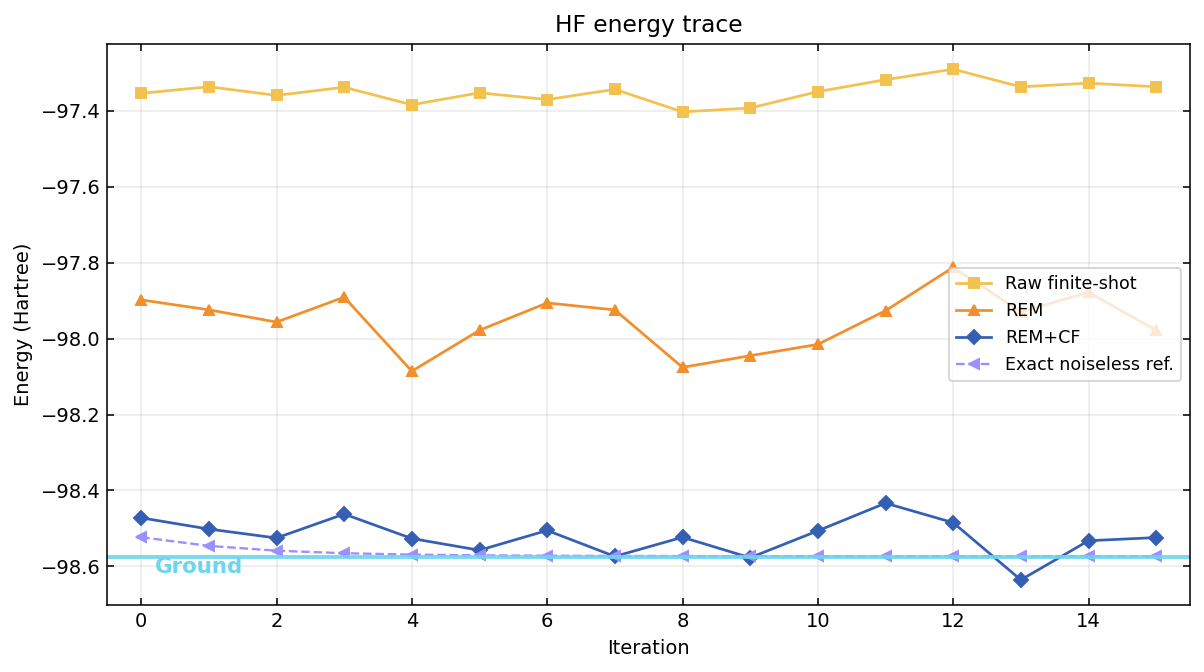

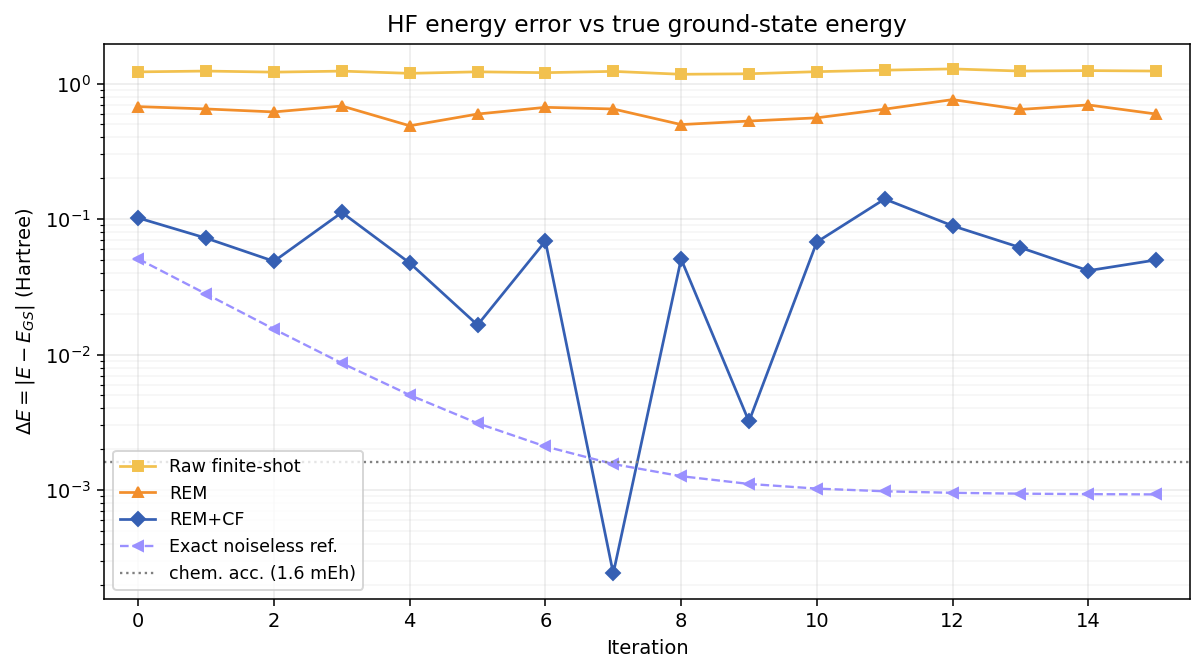

In [3]:
# --- VQE plots from saved cloud data: energy trace + log-scale error vs true GS ---
if vqe_results is None:
    print("No VQE results found in", RUN_DIR)
else:
    ec = vqe_results["energy_curves"]
    xs = as_float_array(ec, "iter")
    raw = as_float_array(ec, "raw_eh")
    rem = as_float_array(ec, "rem_eh")
    cf = as_float_array(ec, "rem_cf_eh")
    nls = as_float_array(ec, "noiseless_eh")

    style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
    style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
    style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="REM+CF")
    style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless ref.")

    # ---- Energy trace ----
    fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
    ax1.plot(xs, raw, **style_raw)
    ax1.plot(xs, rem, **style_rem)
    ax1.plot(xs, cf, **style_cf)
    ax1.plot(xs, nls, **style_nls)
    ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
    ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed", va="top", ha="left", fontsize=11, weight="bold")

    all_e = np.concatenate([raw, rem, cf, nls, [e_ref]])
    lo, hi = float(all_e.min()), float(all_e.max())
    pad = 0.05 * (hi - lo + 1e-9)
    ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax1.set_ylim(lo - pad, hi + pad)
    ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Energy (Hartree)")
    ax1.set_title(f"{molecule} energy trace")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="best", fontsize=9)
    fig1.tight_layout()

    # ---- Absolute error vs true GS (log-y) ----
    floor = 1e-16
    err_raw = np.maximum(np.abs(raw - e_ref), floor)
    err_rem = np.maximum(np.abs(rem - e_ref), floor)
    err_cf = np.maximum(np.abs(cf - e_ref), floor)
    err_nls = np.maximum(np.abs(nls - e_ref), floor)

    fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
    ax2.plot(xs, err_raw, **style_raw)
    ax2.plot(xs, err_rem, **style_rem)
    ax2.plot(xs, err_cf, **style_cf)
    ax2.plot(xs, err_nls, **style_nls)
    ax2.set_yscale("log")
    ax2.axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
    ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
    ax2.set_title(f"{molecule} energy error vs true ground-state energy")
    ax2.grid(True, which="major", alpha=0.25)
    ax2.grid(True, which="minor", alpha=0.12)
    ax2.legend(loc="best", fontsize=9)
    fig2.tight_layout()

    print(f"Using true GS reference energy: {e_ref:.12f} Eh")
    print(f"Best REM+CF energy: {float(vqe_results['E_best']):.12f} Eh")
    print(f"Best REM+CF error: {abs(float(vqe_results['E_best']) - e_ref):.6e} Eh")
    plt.show()


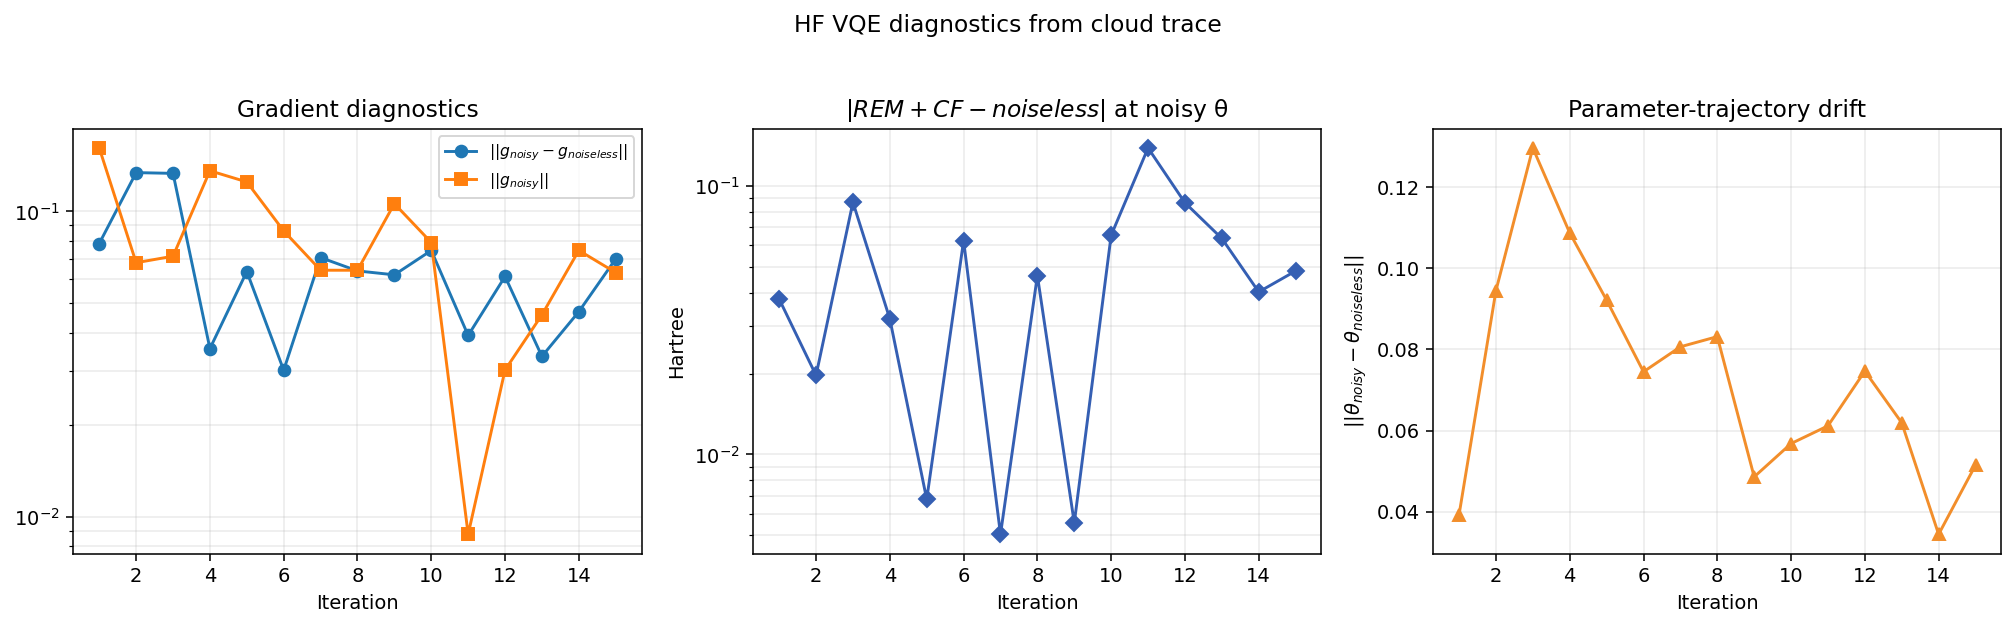

Measurement cost summary
  total CDR calls       : 107
  energy evals/call     : 31
  shots/eval            : 8192
  estimated total shots : 27,172,864
  calls by stage        : {'final': 1, 'init': 1, 'main_grad': 90, 'main_post': 15, 'noiseless_track': 32, 'total': 107, 'warmup': 0}


In [4]:
# --- Extra VQE diagnostics saved by the cloud run ---
if vqe_results is None or not vqe_results.get("trace"):
    print("No VQE trace diagnostics found in", RUN_DIR)
else:
    trace = vqe_results["trace"]
    it = as_float_array(trace, "iter")
    grad_diff = as_float_array(trace, "grad_diff")
    grad_norm = as_float_array(trace, "grad_noisy_norm")
    theta_diff = as_float_array(trace, "theta_diff")
    e_bias = as_float_array(trace, "e_bias")

    fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3))

    axes[0].plot(it, grad_diff, marker="o", lw=1.5, label=r"$||g_{noisy}-g_{noiseless}||$")
    axes[0].plot(it, grad_norm, marker="s", lw=1.5, label=r"$||g_{noisy}||$")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Iteration")
    axes[0].set_title("Gradient diagnostics")
    axes[0].grid(True, which="both", alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].plot(it, e_bias, marker="D", color="#355fb3", lw=1.5)
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Hartree")
    axes[1].set_title(r"$|REM+CF - noiseless|$ at noisy θ")
    axes[1].grid(True, which="both", alpha=0.25)

    axes[2].plot(it, theta_diff, marker="^", color="#f28e2b", lw=1.5)
    axes[2].set_xlabel("Iteration")
    axes[2].set_ylabel(r"$||\theta_{noisy}-\theta_{noiseless}||$")
    axes[2].set_title("Parameter-trajectory drift")
    axes[2].grid(True, alpha=0.25)

    fig.suptitle(f"{molecule} VQE diagnostics from cloud trace", y=1.03)
    fig.tight_layout()
    plt.show()

    cost = vqe_results.get("cost_model", {})
    counts = vqe_results.get("counts", {})
    if cost:
        print("Measurement cost summary")
        print(f"  total CDR calls       : {cost.get('total_cdr_calls', counts.get('total'))}")
        print(f"  energy evals/call     : {cost.get('energy_evals_per_cdr_call')}")
        print(f"  shots/eval            : {cost.get('num_shots_per_eval')}")
        print(f"  estimated total shots : {cost.get('total_shots_est'):,}")
        print(f"  calls by stage        : {counts}")


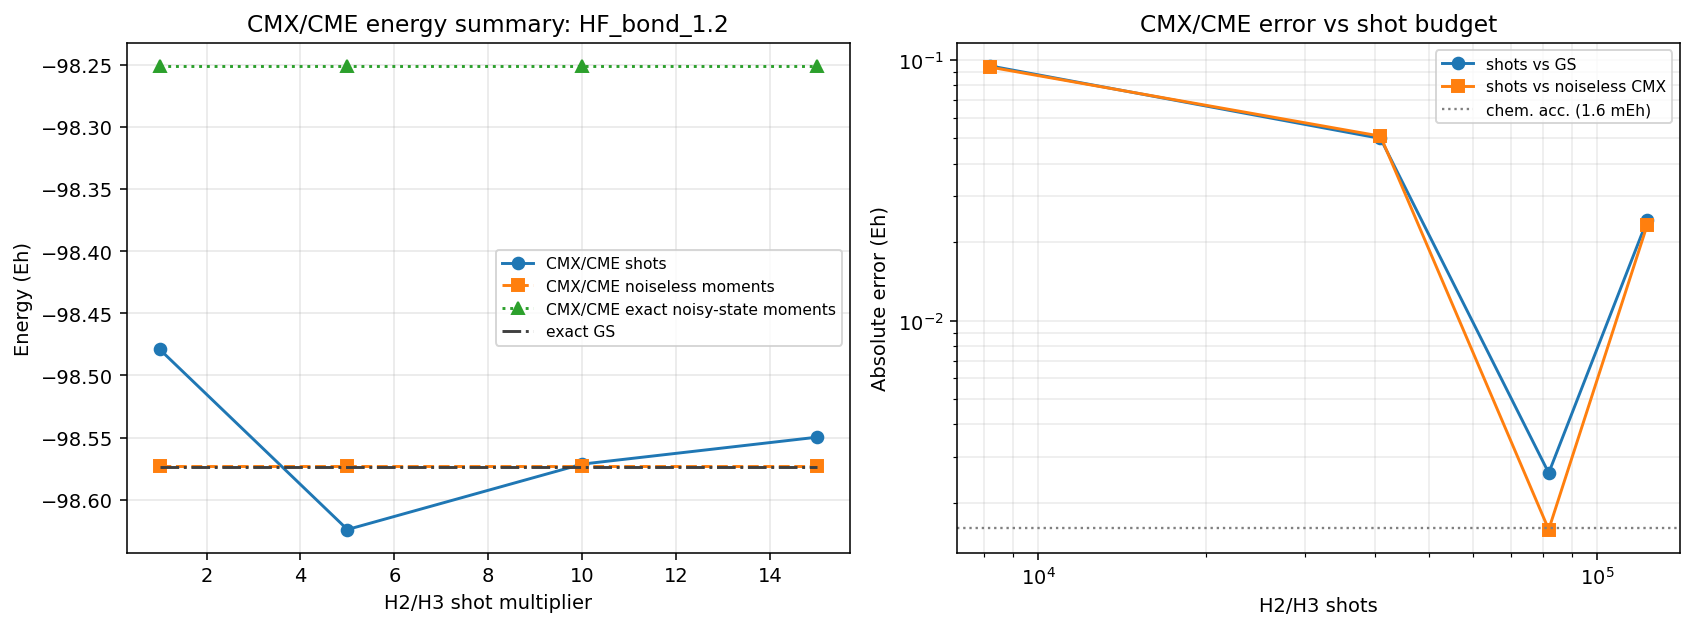

In [5]:
# --- Optional CMX/CME plots when sweep data exists ---
if not cme_by_multiplier:
    print("No non-empty CMX/CME sweep results found in", RUN_DIR)
else:
    items = sorted((int(k), v) for k, v in cme_by_multiplier.items())
    mult = np.asarray([k for k, _ in items], dtype=float)
    e_cme = np.asarray([float(v["E_cme_shots"]) for _, v in items], dtype=float)
    e_cme_noiseless = np.asarray([float(v["E_cme_noiseless"]) for _, v in items], dtype=float)
    e_cme_exact = np.asarray([float(v["E_cme_exact"]) for _, v in items], dtype=float)
    e_gs = np.asarray([float(v["e_gs"]) for _, v in items], dtype=float)
    h2_shots = np.asarray([float(v["shots"]["H2"]) for _, v in items], dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.6))
    axes[0].plot(mult, e_cme, marker="o", label="CMX/CME shots")
    axes[0].plot(mult, e_cme_noiseless, marker="s", linestyle="--", label="CMX/CME noiseless moments")
    axes[0].plot(mult, e_cme_exact, marker="^", linestyle=":", label="CMX/CME exact noisy-state moments")
    axes[0].plot(mult, e_gs, color="0.25", linestyle="-.", label="exact GS")
    axes[0].set_xlabel("H2/H3 shot multiplier")
    axes[0].set_ylabel("Energy (Eh)")
    axes[0].set_title(f"CMX/CME energy summary: {RUN_DIR.name}")
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    axes[1].plot(h2_shots, np.abs(e_cme - e_gs), marker="o", label="shots vs GS")
    axes[1].plot(h2_shots, np.abs(e_cme - e_cme_noiseless), marker="s", label="shots vs noiseless CMX")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].axhline(1.6e-3, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
    axes[1].set_xlabel("H2/H3 shots")
    axes[1].set_ylabel("Absolute error (Eh)")
    axes[1].set_title("CMX/CME error vs shot budget")
    axes[1].grid(True, which="both", alpha=0.25)
    axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()